# Wafer Defects with a ResNet

**Dataset name**: WM-811K wafer map [Kaggle](https://www.kaggle.com/datasets/qingyi/wm811k-wafer-map)

In [1]:
# !pip install pandas kagglehub scikit-learn seaborn -q

In [2]:
import os
import sys
import time
import numpy as np
import pandas as pd # pandas==2.3.3 works for this dataset. If not downgrade
import seaborn as sns
from PIL import Image
from pathlib import Path
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings('ignore', category=np.exceptions.VisibleDeprecationWarning)

SEED = 42

In [4]:
import kagglehub
# kagglehub.login()

path = kagglehub.dataset_download("qingyi/wm811k-wafer-map")
print(path)

/Users/purav/.cache/kagglehub/datasets/qingyi/wm811k-wafer-map/versions/1


In [5]:
print("Loading dataset...")

file_path = "/Users/purav/.cache/kagglehub/datasets/qingyi/wm811k-wafer-map/versions/1/LSWMD.pkl" # Change this to where the LSWMD.pkl is downloaded
# file_path = "../data/LSWMD.pkl"

df_original = pd.read_pickle(file_path)
print(f"Done. {len(df_original)} rows loaded.")

Loading dataset...
Done. 811457 rows loaded.


## Dataset Cleaning

In this section, we will do the following dataset cleaning steps to get our dataset ready for training
1. Rename "trianTestLabel" to "trainTestLabel"
2. Drop samples with unlabeled failureType
3. Drop samples with unlabeled trainTestLabel

1. Rename "trianTestLabel" to "trainTestLabel"

In [6]:
df_original = df_original.rename(columns={"trianTestLabel":"trainTestLabel"})

2. Drop samples with unlabeled `failureType` and unlabeled `trainTestLabel`

In [7]:
df_original["failureType_str"] = df_original["failureType"].astype(str)
df_original["trainTestLabel_str"] = df_original["trainTestLabel"].astype(str)

In [8]:
df_labeled = df_original[
    (df_original["failureType_str"] != "[]") &
    (df_original["trainTestLabel_str"] != "[]")
].copy()

df_labeled[["failureType", "trainTestLabel"]] = (
    df_labeled[["failureType_str", "trainTestLabel_str"]]
    .apply(lambda s: s.str.replace(r"[\[\]']", "", regex=True).str.strip())
)
df_labeled = df_labeled.reset_index(drop=True)

df_labeled contains 172,950 samples that have a `failureType` label.

In [9]:
print(f"df_labeled: {len(df_labeled):,} samples\n")
print(df_labeled["failureType"].value_counts())

df_labeled: 172,950 samples

failureType
none         147431
Edge-Ring      9680
Edge-Loc       5189
Center         4294
Loc            3593
Scratch        1193
Random          866
Donut           555
Near-full       149
Name: count, dtype: int64


## Dataset Prep

In this section, we will do the following pre-processing steps:

1. Wafer Map Shape Normalization
2. Train/Val/Test split

In [10]:
import torch
from torchvision import transforms
from torch.utils.data import Dataset, DataLoader
from scipy.ndimage import label as cc_label
from sklearn.utils.class_weight import compute_class_weight

In [11]:
classes = ["none", "Edge-Ring", "Edge-Loc", "Center", "Loc", "Scratch", "Random", "Donut", "Near-full"]

### 1. Wafer Map Shape Normalization

We have two different strategies to normalize the wafer map shape

1. Resize all wafer map to IMG_SIZExIMG_SIZE (Naive approach)
2. Resize and pad

Additionally, we will also map the pixels [0,2] of the wafer map to to [0,1]

In [12]:
IMG_SIZE  = 64
CLASSES = ["none", "Edge-Ring", "Edge-Loc", "Center", "Loc", "Scratch", "Random", "Donut", "Near-full"]
LABEL_MAP = {c: i for i, c in enumerate(CLASSES)}
print(LABEL_MAP)

{'none': 0, 'Edge-Ring': 1, 'Edge-Loc': 2, 'Center': 3, 'Loc': 4, 'Scratch': 5, 'Random': 6, 'Donut': 7, 'Near-full': 8}


Resize and pad strategy

- Resize while maintaining aspect ratio.
- Resize longest side to target, pad shorter side with zeros (0 = outside wafer).

In [13]:
def resize_and_pad(wm, target=IMG_SIZE):
    """
    Resize while maintaining aspect ratio.
    Resize longest side to target, pad shorter side with zeros (0 = outside wafer).
    """
    h, w  = wm.shape
    scale = target / max(h, w)
    new_h, new_w = int(h * scale), int(w * scale)

    wm_img = Image.fromarray(wm).resize((new_w, new_h), Image.NEAREST)

    pad_h = target - new_h
    pad_w = target - new_w
    wm_padded = np.pad(
        np.array(wm_img),
        ((pad_h // 2, pad_h - pad_h // 2),
         (pad_w // 2, pad_w - pad_w // 2)),
        mode="constant",
        constant_values=0
    )
    return wm_padded

Augmentations

In [14]:
AUGMENTATION = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),
    transforms.RandomChoice([
        transforms.Lambda(lambda x: x), # no rotation
        transforms.RandomRotation(degrees=(90, 90), interpolation=transforms.InterpolationMode.NEAREST),
        transforms.RandomRotation(degrees=(180, 180), interpolation=transforms.InterpolationMode.NEAREST),
        transforms.RandomRotation(degrees=(270, 270), interpolation=transforms.InterpolationMode.NEAREST),
    ]),
])

Over/Undersampling

In [15]:
def balance_df(df, oversample=False, oversample_target=2000, undersample=False, undersample_target=50000):
    """
    Apply oversampling and/or undersampling to a dataframe based on failureType.
    Args:
        df: dataframe with failureType column
        oversample: if True, upsample minority classes to oversample_target (excludes "none")
        oversample_target: minimum number of samples per class after oversampling
        undersample: if True, downsample "none" class to undersample_target
        undersample_target: max number of "none" samples after undersampling
    """
    if oversample:
        oversampled = []
        for cls in CLASSES:
            cls_df = df[df["failureType"] == cls]
            if cls != "none" and len(cls_df) < oversample_target:
                extra = cls_df.sample(oversample_target - len(cls_df), replace=True, random_state=SEED)
                cls_df = pd.concat([cls_df, extra])
            oversampled.append(cls_df)
        df = pd.concat(oversampled).sample(frac=1, random_state=SEED)

    if undersample and undersample_target is not None:
        none_df  = df[df["failureType"] == "none"].sample(undersample_target, random_state=SEED)
        other_df = df[df["failureType"] != "none"]
        df = pd.concat([none_df, other_df])

    return df.reset_index(drop=True)

Wafer Dataset Class

In [16]:
class WaferDataset(Dataset):
    """
    Wafer dataset for CNN training.
    Returns only the wafer tensor with label.
    """
    def __init__(self, df, strategy="pad", augment=False):
        """
        Args:
            df: dataframe with waferMap column
            strategy: "pad" - preserve aspect ratio, pad remainder with zeros
                      "resize" - stretch to IMG_SIZE x IMG_SIZE
            augment: if True, apply random flips and 90° rotations
        """
        self.df = df.reset_index(drop=True)
        self.strategy = strategy
        self.augment = augment

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        # Map values to [0,1]
        wm  = np.array(row["waferMap"], dtype=np.float32) / 2.0

        # Shape Normalization
        if self.strategy == "pad": # Resize and pad to IMG_SIZE
            wm_array = resize_and_pad(wm)
        else: # resize to IMG_SIZE
            wm_array = np.array(Image.fromarray(wm).resize((IMG_SIZE, IMG_SIZE), Image.NEAREST))
            
        wm_tensor = torch.from_numpy(wm_array).unsqueeze(0)  # (1, H, W)
        label = LABEL_MAP[row["failureType"]]

        # Augmentations
        if self.augment:
            wm_tensor = AUGMENTATION(wm_tensor)

        return wm_tensor, label

Visualise a sample before and after each resizing strategy

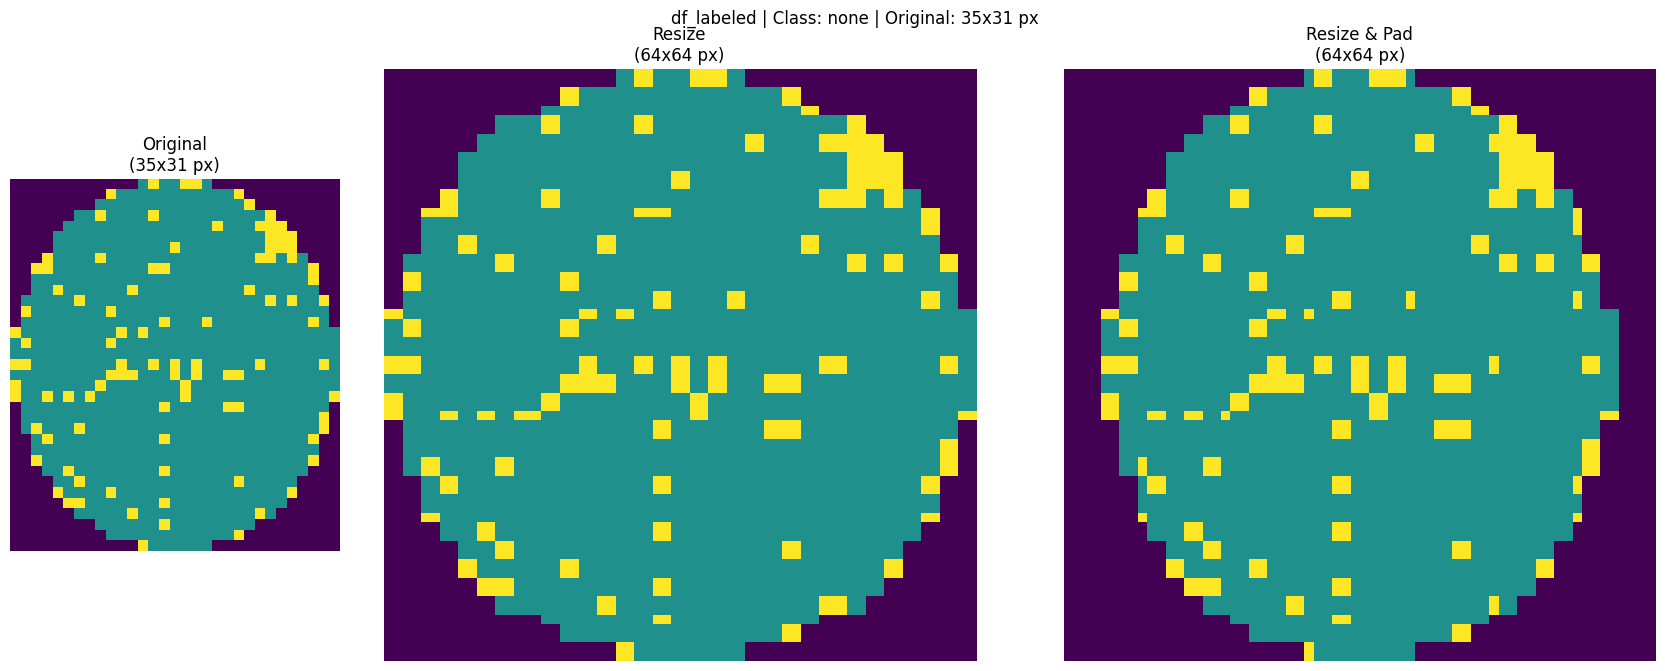

In [17]:
sample_row = df_labeled.sample(1, random_state=np.random.randint(0, 10000)).iloc[0]
wm_raw = np.array(sample_row["waferMap"], dtype=np.float32) / 2.0
wm_resize = np.array(Image.fromarray(wm_raw).resize((IMG_SIZE, IMG_SIZE), Image.NEAREST))
wm_pad = resize_and_pad(wm_raw)

h, w = wm_raw.shape
scale = 0.1
total_w = w + IMG_SIZE + IMG_SIZE
fig = plt.figure(figsize=(total_w * scale + 1, max(h, IMG_SIZE) * scale + 1))

ax1 = fig.add_axes([0/total_w, 0.1, w/total_w, 0.8])
ax2 = fig.add_axes([w/total_w, 0.1, IMG_SIZE/total_w, 0.8])
ax3 = fig.add_axes([(w+IMG_SIZE)/total_w, 0.1, IMG_SIZE/total_w, 0.8])

ax1.imshow(wm_raw, cmap="viridis", interpolation="nearest")
ax1.set_title(f"Original\n({h}x{w} px)")
ax2.imshow(wm_resize, cmap="viridis", interpolation="nearest")
ax2.set_title(f"Resize\n({IMG_SIZE}x{IMG_SIZE} px)")
ax3.imshow(wm_pad, cmap="viridis", interpolation="nearest")
ax3.set_title(f"Resize & Pad\n({IMG_SIZE}x{IMG_SIZE} px)")

for ax in [ax1, ax2, ax3]:
    ax.axis("off")

plt.suptitle(f"df_labeled | Class: {sample_row['failureType']} | Original: {h}x{w} px", fontsize=12)
plt.show()

### 2. Train/Val/Test Split

There are two different strategies to split the dataset
- Use the split provided by the dataset
- Use a stratified split based on `trainTestLabel`

In [18]:
from sklearn.model_selection import train_test_split

In [19]:
torch.manual_seed(SEED)
np.random.seed(SEED)

BATCH_SIZE = 128
# NUM_WORKERS = 8 # number of cores / 2
NUM_WORKERS = 0

# Choose the normalization strategy
STRATEGY = "pad"  # "resize" or "pad"

# Augmentations
AUGMENTATIONS = True

# Oversampling
OVERSAMPLE = True
OVERSAMPLE_TARGET = 2000

# Undersampling
UNDERSAMPLE = True
UNDERSAMPLE_TARGET = 50000

VAL_SPLIT  = 0.1 # % of dataset used as validation set
TEST_SPLIT = 0.2 # % of dataset used as test set

In [20]:
# Uncomment to use original dataset train/test split

# df_train = df[df["trainTestLabel"] == "Training"]
# df_test  = df[df["trainTestLabel"] == "Test"]

# # Carve out VAL_SPLIT% of training set as validation, stratified to preserve class distribution
# df_train_final, df_val = train_test_split(
#     df_train,
#     test_size=VAL_SPLIT,
#     random_state=SEED,
#     stratify=df_train["failureType"]
# )


Use a stratified split to create train/val/test using `failureType`

In [21]:
df_train_val, df_test = train_test_split(
    df_labeled,
    test_size=TEST_SPLIT,
    random_state=SEED,
    stratify=df_labeled["failureType"]
)
df_train_final, df_val = train_test_split(
    df_train_val,
    test_size=VAL_SPLIT / (1 - TEST_SPLIT),
    random_state=SEED,
    stratify=df_train_val["failureType"]
)

In [22]:
df_train_balanced = balance_df(
    df_train_final, 
    oversample=OVERSAMPLE, 
    oversample_target=OVERSAMPLE_TARGET, 
    undersample=UNDERSAMPLE, 
    undersample_target=UNDERSAMPLE_TARGET
)

Create pytorch train/val/test dataloaders

In [23]:
train_loader = DataLoader(WaferDataset(
        df_train_balanced,
        strategy=STRATEGY,
        augment=AUGMENTATIONS,
    ),
    batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS
)
val_loader  = DataLoader(WaferDataset(
        df_val, strategy=STRATEGY
    ), batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS
)
test_loader = DataLoader(WaferDataset(
        df_test, strategy=STRATEGY
    ), batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS
)

In [24]:
print(f"Batch size: {BATCH_SIZE}")
print(f"Num workers: {NUM_WORKERS}")
print(f"Strategy: {STRATEGY}\n")
print(f"Augmentations: {AUGMENTATIONS}")
print(f"Oversample: {OVERSAMPLE} | Oversample Target: {OVERSAMPLE_TARGET}")
print(f"Undersample: {UNDERSAMPLE} | Undersample Target: {UNDERSAMPLE_TARGET}\n")
print(f"Train: {len(train_loader.dataset)} | Val: {len(df_val)} | Test: {len(df_test)}")
x, y = next(iter(train_loader))
print(f"Batch shape: {x.shape}")
print(f"Pixel range: {x.min():.2f} - {x.max():.2f}")

print("\n--- Split Counts ---")
print(f"{'Class':<12} {'Train':>8} {'Val':>8} {'Test':>8}")
print("-" * 40)
for cls in classes:
    train_count = (train_loader.dataset.df["failureType"] == cls).sum()
    val_count   = (val_loader.dataset.df["failureType"]   == cls).sum()
    test_count  = (test_loader.dataset.df["failureType"]  == cls).sum()
    print(f"{cls:<12} {train_count:>8} {val_count:>8} {test_count:>8}")
print("-" * 40)
print(f"{'Total':<12} {len(train_loader.dataset):>8} {len(val_loader.dataset):>8} {len(test_loader.dataset):>8}")

Batch size: 128
Num workers: 0
Strategy: pad

Augmentations: True
Oversample: True | Oversample Target: 2000
Undersample: True | Undersample Target: 50000

Train: 73930 | Val: 17295 | Test: 34590
Batch shape: torch.Size([128, 1, 64, 64])
Pixel range: 0.00 - 1.00

--- Split Counts ---
Class           Train      Val     Test
----------------------------------------
none            50000    14743    29486
Edge-Ring        6776      968     1936
Edge-Loc         3632      519     1038
Center           3006      429      859
Loc              2516      359      718
Scratch          2000      119      239
Random           2000       87      173
Donut            2000       56      111
Near-full        2000       15       30
----------------------------------------
Total           73930    17295    34590


## CNN Training

We've established a CNN architecture for this task called CNN_LARGE

The ideal workflow for training is as follows:
1. Create or use an existing [architecture](#Architectures)
2. Create a training loop in [Model Training](#Model-Training)
3. Evaluate the trained mode in the [Evaluation](#Evaluation) section using the helpers

Refer to the [Google Sheet](https://docs.google.com/spreadsheets/d/1EEcb5PDYZJYiHAMukCWQQq_caa4rk-uP/edit?usp=drive_link&ouid=115259893505039818868&rtpof=true&sd=true) for more information on the experiments ran

In [25]:
import torch.nn as nn
import torch.nn.functional as F

In [26]:
# Use GPU if available
device = torch.device(
    "mps" if torch.backends.mps.is_available() else
    "cuda" if torch.cuda.is_available() else
    "cpu"
)
print(f"Device: {device}")

Device: mps


### Architectures

#### ResNet18

In [27]:
from torchvision.models import resnet18

class ResNet18(nn.Module):
    def __init__(self, num_classes=9):
        super().__init__()
        self.backbone = resnet18(weights=None)
        self.backbone.conv1 = nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3, bias=False)
        self.backbone.fc = nn.Linear(self.backbone.fc.in_features, num_classes)
    def forward(self, x):
        return self.backbone(x)

resnet = ResNet18(num_classes=9).to(device)
total_params = sum(p.numel() for p in resnet.parameters() if p.requires_grad)
print(f"Total trainable parameters: {total_params:,}")

Total trainable parameters: 11,174,857


In [28]:
resnet

ResNet18(
  (backbone): ResNet(
    (conv1): Conv2d(1, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (1): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_r

### Model Training


In [29]:
from torch.optim import Adam
from torch.optim.lr_scheduler import CosineAnnealingLR
from tqdm.notebook import tqdm
from sklearn.metrics import classification_report, ConfusionMatrixDisplay, confusion_matrix, f1_score

results = {}

In [32]:
resnet = ResNet18().to(device)

learning_rate = 1e-4
weight_decay  = 1e-2
eta_min = 1e-6

MAX_EPOCHS = 100
PATIENCE = 20
T_MAX = 50

LABEL_SMOOTHING = 0.1

criterion = nn.CrossEntropyLoss(label_smoothing=LABEL_SMOOTHING)
optimizer = torch.optim.AdamW(resnet.parameters(), lr=learning_rate, weight_decay=weight_decay)
# scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=T_MAX, eta_min=eta_min)

In [33]:
train_losses, val_losses, val_accs, val_f1s, lrs = [], [], [], [], []
best_loss = [float("inf"), 0] # [val loss, train loss]
best_f1 = [-1.0, float("inf"), 0]  # [val f1, val loss, train loss]
patience_counter = 0
best_weights = None

start_time = time.time()

for epoch in tqdm(range(MAX_EPOCHS), desc="Epochs"):
    # Train
    resnet.train()
    running_loss = 0
    for x, y in tqdm(train_loader, desc=f"Epoch {epoch+1}", leave=False):
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad(set_to_none=True)
        loss = criterion(resnet(x), y)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    train_loss = running_loss / len(train_loader)

    # Val
    resnet.eval()
    running_loss = 0
    correct = 0
    total = 0
    all_preds, all_labels = [], []
    with torch.no_grad():
        for x, y in val_loader:
            x, y = x.to(device), y.to(device)
            logits = resnet(x)
            running_loss += criterion(logits, y).item()
            preds = logits.argmax(1)
            correct += (preds == y).sum().item()
            total += y.size(0)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(y.cpu().numpy())
    val_loss = running_loss / len(val_loader)
    val_acc = correct / total
    val_f1 = f1_score(all_labels, all_preds, average="macro", zero_division=0)

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    val_accs.append(val_acc)
    val_f1s.append(val_f1)
    lrs.append(optimizer.param_groups[0]["lr"])

    # Uncomment if cosine annealing is turned on
    # scheduler.step()

    if val_loss < best_loss[0]:
        best_loss[0] = val_loss
        best_loss[1] = train_loss
        
    # Early stopping on val F1
    if val_f1 > best_f1[0]:
        best_f1[0] = val_f1
        best_f1[1] = val_loss
        best_f1[2] = train_loss
        patience_counter = 0
        best_weights = {k: v.clone() for k, v in resnet.state_dict().items()}
    else:
        patience_counter += 1

    tqdm.write(
        f"Epoch {epoch+1:02d} | "
        f"Train: {train_loss:.4f} | "
        f"Val: {val_loss:.4f} | "
        # f"Val Acc: {val_acc:.4f} | "
        f"Val F1: {val_f1:.4f} | "
        f"LR: {optimizer.param_groups[0]['lr']:.2e} | "
        f"Patience: {patience_counter}/{PATIENCE}"
    )

    if patience_counter >= PATIENCE:
        tqdm.write(f"Early stopping at epoch {epoch+1}")
        break

elapsed = time.time() - start_time
resnet.load_state_dict(best_weights)
tqdm.write(f"Restored best model — val F1: {best_f1[0]:.4f} | val loss at that epoch: {best_f1[1]:.4f}")

results["resnet"] = {
    "metrics": {
        "train_losses": train_losses,
        "val_losses": val_losses,
        "val_accs": val_accs,
        "val_f1s": val_f1s
    },
    "best_val_f1": best_f1[0],
    "best_val_loss_at_f1": best_f1[1],
    "best_train_loss_at_f1": best_f1[2],
    "best_val_loss": best_loss[0],
    "best_train_loss_at_loss": best_loss[1],
    "epochs_trained": len(train_losses),
    "training_time_sec": elapsed,
    "hyperparams": {
        "batch_size": train_loader.batch_size,
        "learning_rate": learning_rate,
        "lrs": lrs,
        "weight_decay": weight_decay,
        "scheduler": "None",
        "max_epochs": MAX_EPOCHS,
        "patience": PATIENCE,
        "label_smoothing": LABEL_SMOOTHING
    },
    "dataset": {
        "strategy": STRATEGY,
        "augmentations": AUGMENTATIONS,
        "oversample": OVERSAMPLE,
        "oversample_target": OVERSAMPLE_TARGET,
        "undersample": UNDERSAMPLE,
        "undersample_target": UNDERSAMPLE_TARGET,
        "n_train": len(train_loader.dataset),
        "n_val": len(val_loader.dataset),
        "n_test": len(test_loader.dataset)
    }
}

print(f"\nTraining Time: {results['resnet']['training_time_sec']/60:.4f} min")

Epochs:   0%|          | 0/100 [00:00<?, ?it/s]

Epoch 1:   0%|          | 0/578 [00:00<?, ?it/s]

Epoch 01 | Train: 0.7664 | Val: 0.5930 | Val F1: 0.7621 | LR: 1.00e-04 | Patience: 0/20


Epoch 2:   0%|          | 0/578 [00:00<?, ?it/s]

Epoch 02 | Train: 0.6566 | Val: 0.5802 | Val F1: 0.7730 | LR: 1.00e-04 | Patience: 0/20


...

Epoch 39 | Train: 0.5170 | Val: 0.5730 | Val F1: 0.8461 | LR: 1.00e-04 | Patience: 18/20


Epoch 40:   0%|          | 0/578 [00:00<?, ?it/s]

Epoch 40 | Train: 0.5168 | Val: 0.5572 | Val F1: 0.8496 | LR: 1.00e-04 | Patience: 19/20


Epoch 41:   0%|          | 0/578 [00:00<?, ?it/s]

Epoch 41 | Train: 0.5160 | Val: 0.5585 | Val F1: 0.8530 | LR: 1.00e-04 | Patience: 20/20
Early stopping at epoch 41
Restored best model — val F1: 0.8751 | val loss at that epoch: 0.5461

Training Time: 5.4844 min


## Evaluation

In this section, we evaluate the models we trained in the above section. 

For each model, there are three evaluation metrics displayed
1. Per class metrics
2. Loss curve
3. Confusion matrix

In [34]:
# Uncomment if loading saved weights

# model_path = "checkpoints/best/resnet.pt" # change to where the weights are saved
# resnet = ResNet18().to(device)

# if os.path.exists(model_path):
#     ckpt = torch.load(model_path, map_location=device, weights_only=False)
#     resnet.load_state_dict(ckpt["model_state_dict"])
#     results["resnet"] = ckpt["results"]
#     print(f"Loaded {model_path}")
# else:
#     print(f"No checkpoint at {model_path}")

### Helpers

In [35]:
def evaluate_model(model, loader, run_name):
    model.eval()
    all_preds, all_labels = [], []
    test_running_loss = 0
    criterion_eval = nn.CrossEntropyLoss(label_smoothing=LABEL_SMOOTHING)
    with torch.no_grad():
        for x, y in tqdm(loader, desc=f"Evaluating {run_name}"):
            x, y = x.to(device), y.to(device)
            out = model(x)
            test_running_loss += criterion_eval(out, y).item()
            preds = out.argmax(dim=1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(y.cpu().numpy())
    test_loss = round(test_running_loss / len(loader), 4)
    all_preds = np.array(all_preds)
    all_labels = np.array(all_labels)
    report = classification_report(all_labels, all_preds, target_names=classes, output_dict=True, zero_division=0)
    cm = confusion_matrix(all_labels, all_preds)

    results[run_name].update({
        "test": {
            "accuracy": round(report["accuracy"], 4),
            "macro_f1": round(report["macro avg"]["f1-score"], 4),
            "macro_precision": round(report["macro avg"]["precision"], 4),
            "macro_recall": round(report["macro avg"]["recall"], 4),
            "test_loss": test_loss,
            "preds": all_preds,
            "labels": all_labels,
            **{f"f1_{cls}": round(report[cls]["f1-score"], 4) for cls in classes},
        }
    })

    best_val_loss = results[run_name]["best_val_loss_at_f1"]
    best_train_loss = results[run_name]["best_train_loss_at_f1"]

    print(f"\n--- {run_name} ---")
    print(f"Train Loss: {best_train_loss:.4f} | Val Loss: {best_val_loss:.4f} | Test Loss: {test_loss:.4f}")
    print(f"\nPer-class Metrics:")
    print(f"{'Class':<12} {'F1':>10} {'Precision':>10} {'Recall':>10}")
    print("-" * 46)
    for cls in classes:
        print(
            f"{cls:<12} "
            f"{report[cls]['f1-score']:>10.4f} "
            f"{report[cls]['precision']:>10.4f} "
            f"{report[cls]['recall']:>10.4f}"
        )
    print("-" * 46)
    print(
        f"{'macro avg':<12} "
        f"{report['macro avg']['f1-score']:>10.4f} "
        f"{report['macro avg']['precision']:>10.4f} "
        f"{report['macro avg']['recall']:>10.4f}"
    )
    print(f"\nOverall Accuracy: {report['accuracy']:.4f}")
    print(f"\nTraining Time: {results[run_name]['training_time_sec']/60:.4f} min")

In [36]:
def plot_losses(run_name):
    train = results[run_name]["metrics"]["train_losses"]
    val = results[run_name]["metrics"]["val_losses"]
    best_val = results[run_name]["best_val_loss"]
    best_val_epoch = val.index(best_val)
    best_train = min(train)
    
    plt.figure(figsize=(6, 4))
    plt.plot(train, label=f"Train (best: {best_train:.4f})")
    plt.plot(val, label=f"Val (best: {best_val:.4f})")
    plt.axhline(best_val, color="red", linestyle="--", linewidth=0.8)
    plt.axvline(best_val_epoch, color="red", linestyle="--", linewidth=0.8)
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(f"{run_name} — Loss Curve")
    plt.legend()
    plt.tight_layout()
    plt.show()


def plot_val_metrics(run_name):
    val_accs = results[run_name]["metrics"]["val_accs"]
    val_f1s = results[run_name]["metrics"]["val_f1s"]
    best_acc = max(val_accs)
    best_acc_epoch = val_accs.index(best_acc)
    best_f1 = max(val_f1s)
    best_f1_epoch = val_f1s.index(best_f1)
    
    plt.figure(figsize=(6, 4))
    plt.plot(val_accs, label=f"Val Acc (best: {best_acc:.4f})", color="C0")
    plt.plot(val_f1s, label=f"Val Macro F1 (best: {best_f1:.4f})", color="C1")
    plt.axhline(best_acc, color="C0", linestyle="--", linewidth=0.8)
    plt.axhline(best_f1, color="C1", linestyle="--", linewidth=0.8)
    plt.axvline(best_f1_epoch, color="C1", linestyle="--", linewidth=0.8)
    plt.xlabel("Epoch")
    plt.ylabel("Score")
    plt.title(f"{run_name} — Val Accuracy & F1")
    plt.legend()
    plt.tight_layout()
    plt.show()


def plot_lr(run_name):
    lrs = results[run_name]["hyperparams"]["lrs"]
    plt.figure(figsize=(6, 4))
    plt.plot(lrs)
    plt.xlabel("Epoch")
    plt.ylabel("Learning Rate")
    plt.title(f"{run_name} — Learning Rate Schedule")
    plt.yscale("log")
    plt.tight_layout()
    plt.show()

### Results

In [37]:
evaluate_model(resnet, test_loader, "resnet")

Evaluating resnet:   0%|          | 0/271 [00:00<?, ?it/s]


--- resnet ---
Train Loss: 0.5408 | Val Loss: 0.5461 | Test Loss: 0.5456

Per-class Metrics:
Class                F1  Precision     Recall
----------------------------------------------
none             0.9896     0.9861     0.9931
Edge-Ring        0.9734     0.9741     0.9726
Edge-Loc         0.8147     0.8558     0.7775
Center           0.9344     0.9317     0.9371
Loc              0.7365     0.7961     0.6852
Scratch          0.6572     0.7554     0.5816
Random           0.8914     0.8602     0.9249
Donut            0.8245     0.7537     0.9099
Near-full        0.9355     0.9062     0.9667
----------------------------------------------
macro avg        0.8619     0.8688     0.8610

Overall Accuracy: 0.9742

Training Time: 5.4844 min


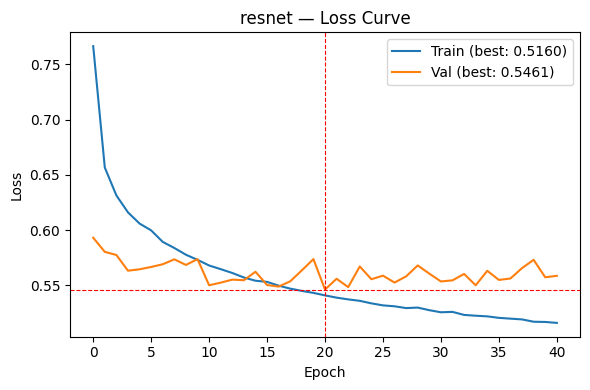

In [38]:
plot_losses("resnet")

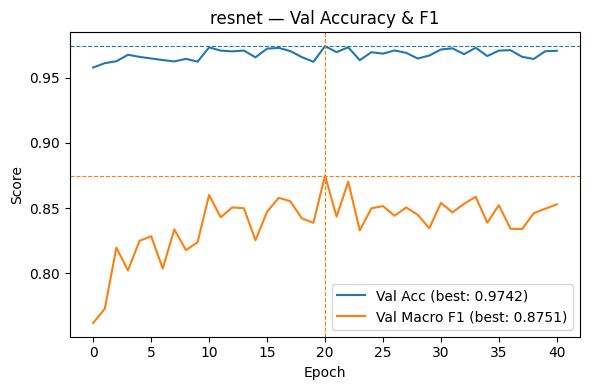

In [39]:
plot_val_metrics("resnet")

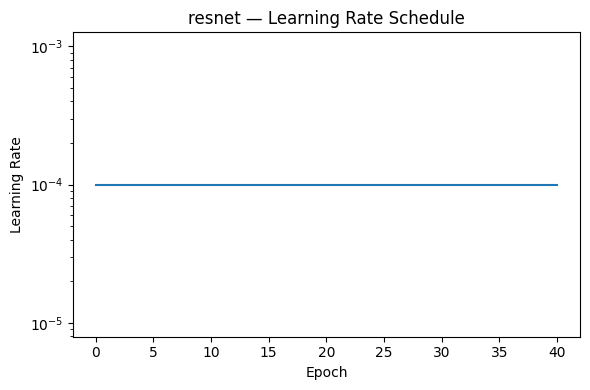

In [40]:
plot_lr("resnet")

Save model

In [41]:
def save_checkpoint(model, results, file_name):
    save_dir = Path("checkpoints")
    save_dir.mkdir(parents=True, exist_ok=True)

    save_path = save_dir / f"{file_name}.pt"

    torch.save({
        "model_state_dict": model.state_dict(),
        "results": results
    }, save_path)

    print(f"Checkpoint saved to: {save_path}")

In [42]:
save_checkpoint(resnet, results["resnet"], "resnet")

Checkpoint saved to: checkpoints/resnet.pt


Test Time Augmentations

In [43]:
from scipy.optimize import minimize

def get_probs(model, loader):
    """Return (probs, labels) as numpy arrays."""
    model.eval()
    all_probs, all_labels = [], []
    with torch.no_grad():
        for x, y in loader:
            x = x.to(device)
            probs = torch.softmax(model(x), dim=1).cpu().numpy()
            all_probs.append(probs)
            all_labels.append(y.numpy())
    return np.concatenate(all_probs), np.concatenate(all_labels)


def tune_thresholds(model, val_loader, test_loader, run_name):
    """Tune per-class thresholds on val probs, evaluate on test."""
    val_probs, val_labels = get_probs(model, val_loader)
    test_probs, test_labels = get_probs(model, test_loader)
    
    def neg_macro_f1(thresholds, probs, labels):
        preds = (probs / thresholds).argmax(axis=1)
        return -f1_score(labels, preds, average="macro", zero_division=0)
    
    result = minimize(
        neg_macro_f1,
        x0=np.ones(len(classes)),
        args=(val_probs, val_labels),
        method="Nelder-Mead",
        options={"xatol": 1e-4, "fatol": 1e-4, "maxiter": 2000}
    )
    best_thresholds = result.x
    val_f1_tuned = -result.fun
    val_f1_baseline = f1_score(val_labels, val_probs.argmax(axis=1),
                                average="macro", zero_division=0)
    
    test_preds_tuned = (test_probs / best_thresholds).argmax(axis=1)
    test_preds_baseline = test_probs.argmax(axis=1)
    
    report_tuned = classification_report(
        test_labels, test_preds_tuned,
        target_names=classes, output_dict=True, zero_division=0
    )
    report_baseline = classification_report(
        test_labels, test_preds_baseline,
        target_names=classes, output_dict=True, zero_division=0
    )
    
    results[run_name].update({
        "test_tuned": {
            "accuracy": round(report_tuned["accuracy"], 4),
            "macro_f1": round(report_tuned["macro avg"]["f1-score"], 4),
            "macro_precision": round(report_tuned["macro avg"]["precision"], 4),
            "macro_recall": round(report_tuned["macro avg"]["recall"], 4),
            "preds": test_preds_tuned,
            "labels": test_labels,
            "probs": test_probs,
            "thresholds": best_thresholds,
            "val_f1_baseline": round(val_f1_baseline, 4),
            "val_f1_tuned": round(val_f1_tuned, 4),
            **{f"f1_{cls}": round(report_tuned[cls]["f1-score"], 4) for cls in classes},
        }
    })
    
    print(f"\n--- {run_name} (threshold-tuned) ---")
    print(f"Val F1:  baseline {val_f1_baseline:.4f}  ->  tuned {val_f1_tuned:.4f}  (Change: {val_f1_tuned - val_f1_baseline:+.4f})")
    print(f"\nTuned Thresholds:")
    for cls, t in zip(classes, best_thresholds):
        print(f"  {cls:<12} {t:.4f}")
    
    print(f"\nPer-class Metrics (test):")
    print(f"{'Class':<12} {'F1 base':>10} {'F1 tuned':>10} {'Change':>8} {'Prec':>10} {'Recall':>10}")
    print("-" * 62)
    for cls in classes:
        f1_b = report_baseline[cls]["f1-score"]
        f1_t = report_tuned[cls]["f1-score"]
        print(
            f"{cls:<12} "
            f"{f1_b:>10.4f} "
            f"{f1_t:>10.4f} "
            f"{f1_t - f1_b:>+8.4f} "
            f"{report_tuned[cls]['precision']:>10.4f} "
            f"{report_tuned[cls]['recall']:>10.4f}"
        )
    print("-" * 62)
    print(
        f"{'macro avg':<12} "
        f"{report_baseline['macro avg']['f1-score']:>10.4f} "
        f"{report_tuned['macro avg']['f1-score']:>10.4f} "
        f"{report_tuned['macro avg']['f1-score'] - report_baseline['macro avg']['f1-score']:>+8.4f} "
        f"{report_tuned['macro avg']['precision']:>10.4f} "
        f"{report_tuned['macro avg']['recall']:>10.4f}"
    )
    print(f"\nOverall Accuracy: {report_tuned['accuracy']:.4f}")

In [44]:
tune_thresholds(resnet, val_loader, test_loader, "resnet")


--- resnet (threshold-tuned) ---
Val F1:  baseline 0.8751  ->  tuned 0.8774  (Change: +0.0024)

Tuned Thresholds:
  none         0.8883
  Edge-Ring    1.0320
  Edge-Loc     0.9849
  Center       1.0339
  Loc          0.9825
  Scratch      1.0158
  Random       1.0150
  Donut        1.0555
  Near-full    0.9942

Per-class Metrics (test):
Class           F1 base   F1 tuned   Change       Prec     Recall
--------------------------------------------------------------
none             0.9896     0.9896  +0.0000     0.9855     0.9937
Edge-Ring        0.9734     0.9739  +0.0005     0.9756     0.9721
Edge-Loc         0.8147     0.8146  -0.0002     0.8590     0.7746
Center           0.9344     0.9347  +0.0002     0.9368     0.9325
Loc              0.7365     0.7334  -0.0031     0.7984     0.6783
Scratch          0.6572     0.6539  -0.0033     0.7611     0.5732
Random           0.8914     0.8908  -0.0006     0.8641     0.9191
Donut            0.8245     0.8313  +0.0068     0.7652     0.9099
Nea